In [1]:
%load_ext autoreload
%autoreload 2
# Select conda environment base-env with necessary libraries
# mamba activate base-env

In [2]:
# Import generic libraries
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib as mpl
import statsmodels.api as sm

mpl.rcParams['figure.dpi'] = 200


In [3]:
# Import file paths from config.py
from config import CSV_PATHS, GEOJSON_PATHS

# Section 1. Data Manipulation

## Question 1: Load the data and display a few rows of each dataset

In [4]:
# Load data
crime = pd.read_csv(CSV_PATHS['crime'])
stops = pd.read_csv(CSV_PATHS['stops'])

# Consistent lower case column namesfor easier access
crime.columns = crime.columns.str.lower()
stops.columns = stops.columns.str.lower()

In [5]:
# Display crime rows
crime.head()

,x,y,ccn,report_dat,shift,method,offense,block,xblock,yblock,...,block_group,census_tract,voting_precinct,latitude,longitude,bid,start_date,end_date,objectid,octo_record_id
0,-77.058663,38.906846,7093973,2017-06-03T12:54:27.000Z,DAY,OTHERS,THEFT FROM AUTO,2900 - 2999 BLOCK OF N STREET NW,394912,137666,...,000100 4,100.0,Precinct 5,38.906838,-77.058661,NaN,2017-06-03T11:54:03.000Z,2017-06-03T11:55:05.000Z,341397622,07093973-01
1,-77.018036,38.960747,9251904,2017-04-07T00:00:00.000Z,MIDNIGHT,OTHERS,HOMICIDE,5800 - 5899 BLOCK OF 4TH STREET NW,398437,143648,...,001902 1,1902.0,Precinct 58,38.960739,-77.018034,NaN,2009-02-13T12:03:45.000Z,2009-02-13T12:03:43.000Z,341453326,09251904-01
2,-76.984955,38.915147,14060710,2017-03-13T00:00:00.000Z,MIDNIGHT,OTHERS,HOMICIDE,2000 - 2099 BLOCK OF FENWICK STREET NE,401305,138586,...,008803 1,8803.0,Precinct 76,38.915139,-76.984953,NaN,2014-05-01T19:32:00.000Z,2014-05-01T19:32:00.000Z,341600002,14060710-01
3,-77.009722,38.824388,16217337,2017-04-03T00:00:00.000Z,MIDNIGHT,OTHERS,HOMICIDE,2 - 153 BLOCK OF GALVESTON PLACE SW,399156,128511,...,009807 2,9807.0,Precinct 126,38.824380,-77.009719,NaN,2016-12-25T11:59:35.000Z,2016-12-25T20:36:17.000Z,341698884,16217337-01
4,-77.017203,38.904526,17037020,2017-03-05T20:46:01.000Z,EVENING,OTHERS,THEFT FROM AUTO,400 - 471 BLOCK OF NEW YORK AVENUE NW,398508,137407,...,004701 2,4701.0,Precinct 1,38.904518,-77.017201,MOUNT VERNON TRIANGLE CID,2017-03-05T20:14:30.000Z,NaN,341703531,17037020-01


In [6]:
# Display stops rows
stops.head()

,stop_id,officer_id,stop_date,driver_age,driver_sex,ticket
0,52595,E,3/1/2017,37,f,True
1,46141,D,3/1/2017,16,m,True
2,154271,D,3/1/2017,16,m,True
3,184170,D,3/1/2017,23,m,True
4,91155,D,3/1/2017,18,f,True


## Question 2: Crime incidents are reported to hour/minute; stops reported to the day

In [7]:
# Extract date from report date as datetime object and create new column report_daily
crime['report_daily'] = pd.to_datetime(crime['report_dat']).dt.date
print(crime['report_daily'].head())

# Also convert stop_date to datetime object
stops['report_daily'] = pd.to_datetime(stops['stop_date']).dt.date
print(stops['report_daily'].head())

0    2017-06-03
1    2017-04-07
2    2017-03-13
3    2017-04-03
4    2017-03-05
Name: report_daily, dtype: object
0    2017-03-01
1    2017-03-01
2    2017-03-01
3    2017-03-01
4    2017-03-01
Name: report_daily, dtype: object


## Question 3: Create groupby datasets: *crimes_by_day* and *stops_by_day*

In [8]:
# Count number of crimes by day
# NOTE: sort=True is groupby default, but we can be explicit to ensure the dates are in order
crimes_by_day = (crime.groupby(crime['report_daily'], 
                              as_index=False)['objectid']
                             .nunique()
                             .rename(columns={'objectid': 'count'}))

# Confirm number of unique days in report_daily matches number of rows in crimes_by_day
print(crime['report_daily'].nunique())
print(len(crimes_by_day))

# Show crimes by day
crimes_by_day.head()

182
182


,report_daily,count
0,2017-03-01,80
1,2017-03-02,59
2,2017-03-03,84
3,2017-03-04,77
4,2017-03-05,61


In [9]:
# Count number of stops by day
# NOTE: sort=True is groupby default, but we can be explicit to ensure the dates are in order
stops_by_day = (stops.groupby(stops['report_daily'], as_index=False)['stop_id']
                             .nunique()
                             .rename(columns={'stop_id': 'count'}))

# Confirm number of unique days in stop_date matches number of rows in stops_by_day
print(stops['report_daily'].nunique())
print(len(stops_by_day))

# Show stops by day
stops_by_day.head()

174
174


,report_daily,count
0,2017-03-01,509
1,2017-03-02,421
2,2017-03-03,413
3,2017-03-04,475
4,2017-03-05,490


## Question 4: Fill missing dates
Fill missing dates with actual observed values of 0 for purposes of computing statistics. If filled with Nan, statistics would be biased upward.

In [10]:
# Create simple function to fill missing dates in a DataFrame with 0 counts
def fill_missing_dates(
    df: pd.DataFrame, 
    date_col: str = "report_daily", 
    fill_col: str = "count", 
    fill_value: int = 0) -> pd.DataFrame:
    """
    Fill missing dates in a DataFrame with 0 counts.
    """
    # Create complete date range from min to max date
    date_range = pd.date_range(start=df[date_col].min(), end=df[date_col].max(), freq='D')

    # Convert date column to datetime type (if not already)
    df[date_col] = pd.to_datetime(df[date_col])
        
    # Extract dates missing from crimes_by_day 
    idx = ~date_range.isin(df[date_col])
    print(f"{sum(idx)}/{len(date_range)} missing dates.")

    # Append and sort missing dates with fill value
    if sum(idx) > 0:
        
        # Create df with missing dates and fill value
        missing_df = pd.DataFrame({date_col: date_range[idx], fill_col: fill_value})

        # Concatenate missing dates
        df = pd.concat([df, missing_df]).sort_values(by=date_col).reset_index(drop=True)
    
    return df


In [11]:
# Add missing dates to crimes_by_day
crimes_by_day = fill_missing_dates(crimes_by_day)

# Add missing dates to stops_by_day
stops_by_day = fill_missing_dates(stops_by_day)

# Show missing dates with 0 traffic stops
stops_by_day[stops_by_day["count"]==0]

0/182 missing dates.
8/182 missing dates.


,report_daily,count
29,2017-03-30,0
30,2017-03-31,0
60,2017-04-30,0
90,2017-05-30,0
91,2017-05-31,0
121,2017-06-30,0
151,2017-07-30,0
152,2017-07-31,0


# Question 5: Merge traffic stops and crime data

In [12]:
# Merge dfs
df = stops_by_day.merge(crimes_by_day, on="report_daily", how='left', suffixes=('_stops', '_crimes'))
df

,report_daily,count_stops,count_crimes
0,2017-03-01,509,80
1,2017-03-02,421,59
2,2017-03-03,413,84
3,2017-03-04,475,77
4,2017-03-05,490,61
...,...,...,...
177,2017-08-25,475,94
178,2017-08-26,471,114
179,2017-08-27,444,106
180,2017-08-28,476,74


In [13]:
# Date with max traffic stops
max_stops_date, max_stops, _ = df.loc[df['count_stops'].idxmax()]
print(f"Max traffic stops: 1) date: {max_stops_date.strftime('%Y-%m-%d')}, 2) count: {max_stops}, 3) day of week: {max_stops_date.date().strftime('%A')}")

Max traffic stops: 1) date: 2017-05-01, 2) count: 535, 3) day of week: Monday


In [14]:
# Date with max crimes
max_crimes_date, max_crimes, _ = df.loc[df['count_crimes'].idxmax()]
print(f"Max crimes: 1) date: {max_crimes_date.strftime('%Y-%m-%d')}, 2) count: {max_crimes}, 3) day of week: {max_crimes_date.date().strftime('%A')}")

Max crimes: 1) date: 2017-05-08, 2) count: 410, 3) day of week: Monday


## Question 6: most common July 4 crime

In [15]:
# Ensure report_daily is datetime type to use dt accessor
crime['report_daily'] = pd.to_datetime(crime['report_daily'])

# Extract July 4th
idx = (crime['report_daily'].dt.month == 7) & (crime['report_daily'].dt.day == 4)

# Count crimes by offense on July 4th
offense_counts = crime[idx].groupby("offense").size().sort_values(ascending=False)

# Extract most frequent offense on July 4th
print(f"Most frequent July 4 crime: {offense_counts.index[0]}, count: {offense_counts.iloc[0]}")
print(offense_counts)


Most frequent July 4 crime: THEFT FROM AUTO, count: 22
offense
THEFT FROM AUTO               22
THEFT/OTHER                   20
MOTOR VEHICLE THEFT           13
THEFT_OTHER                   11
ROBBERY                        7
ASSAULT W/DANGEROUS WEAPON     6
BURGLARY                       2
THEFT OTHER                    2
dtype: int64


# Section 2: Policy Evaluation

In [ ]:
# NOTE: Courts data has 3 column names, but comma separator produces 4 columns for some rows
# Based on note that traffic tickets are in $0.50 increments, 
# I assume the extra column in some cases is using comma as a decimal separator
# NOTE: I added a dummy column name "ticket_cents" to facilitate the cleaning

# Load data
courts = pd.read_csv(CSV_PATHS['courts'])
courts.head(10)

,stop_id,ticket_amount,ticket_status,dummy
0,175978,40,overdue,NaN
1,63356,40,paid,NaN
2,92046,45,paid,NaN
3,173651,45,overdue,NaN
4,52624,65,paid,NaN
5,147991,47,overdue,NaN
6,9957,55,overdue,NaN
7,186564,40,50,paid
8,106970,45,challenged,NaN
9,65657,30,overdue,NaN


In [ ]:
# Extract ticket cents from ticket_status and fill missing values in ticket_status with ticket_cents
ticket_cents = pd.to_numeric(courts['ticket_status'], errors='coerce').fillna(0)/100
courts['ticket_amount'] += ticket_cents
courts.head(10)

,stop_id,ticket_amount,ticket_status,dummy
0,175978,40.0,overdue,NaN
1,63356,40.0,paid,NaN
2,92046,45.0,paid,NaN
3,173651,45.0,overdue,NaN
4,52624,65.0,paid,NaN
5,147991,47.0,overdue,NaN
6,9957,55.0,overdue,NaN
7,186564,40.5,50,paid
8,106970,45.0,challenged,NaN
9,65657,30.0,overdue,NaN


In [ ]:
# Fill missing values in ticket_status that were right shifted due to ticket_cents
idx = ~courts['dummy'].isna()
courts.loc[idx, 'ticket_status'] = courts[idx]['dummy']
# Drop dummy column
courts.drop(columns=['dummy'], inplace=True)
courts.head(10)


,stop_id,ticket_amount,ticket_status
0,175978,40.0,overdue
1,63356,40.0,paid
2,92046,45.0,paid
3,173651,45.0,overdue
4,52624,65.0,paid
5,147991,47.0,overdue
6,9957,55.0,overdue
7,186564,40.5,paid
8,106970,45.0,challenged
9,65657,30.0,overdue


In [ ]:
# Read courts and income data
income = pd.read_csv(CSV_PATHS['income'])
income.head(10)

,stop_id,income
0,97294,26305
1,87077,77578
2,57432,80185
3,121675,98784
4,37238,9350
5,199246,31981
6,191139,42301
7,153865,52278
8,90007,21719
9,111167,34801


In [ ]:
# Merge courts and income data on stop_id
df = courts.merge(income, on="stop_id", how='left')

# Check lengths of courts, income, and merged df to confirm merge worked as expected
print(len(courts), len(income), len(df))
df.head()

60257 60268 60257


,stop_id,ticket_amount,ticket_status,income
0,175978,40.0,overdue,NaN
1,63356,40.0,paid,104461.0
2,92046,45.0,paid,67931.0
3,173651,45.0,overdue,35424.0
4,52624,65.0,paid,88920.0


## Question 7: delta probability less/greater than $30,000

In [ ]:
INCOME_THRESHOLD = 30000
# Extract low income people
low_income = (df['income'] < INCOME_THRESHOLD)
# Extract low income people with paid tickes
paid_low_income = (df['ticket_status'] == 'paid') & low_income
# Compute probability of paid ticket for low income people
prob_paid_low_income = sum(paid_low_income) / sum(low_income)
print(f"Probability of paid ticket for low income: {prob_paid_low_income:.2%}")

# Extract high income people
high_income = (df['income'] >= INCOME_THRESHOLD)
# Extract high income people with paid tickes
paid_high_income = (df['ticket_status'] == 'paid') & high_income
# Compute probability of paid ticket for high income people
prob_paid_high_income = sum(paid_high_income) / sum(high_income)
print(f"Probability of paid ticket for high income: {prob_paid_high_income:.2%}")


Probability of paid ticket for low income: 35.52%
Probability of paid ticket for high income: 30.16%


In [ ]:
from scipy import stats


In [ ]:
delta_prob = prob_paid_low_income - prob_paid_high_income
delta_prob

0.053536870855838636

In [ ]:

>>> x = [[0, 1], [5, 1], [15, 2], [25, 5], [35, 11], [45, 15], [55, 34], [60, 35]]
>>> y = [4, 5, 20, 14, 32, 22, 38, 43]
>>> x, y = np.array(x), np.array(y)
x = sm.add_constant(x) # Adds the intercept term
model = sm.OLS(y, x).fit()
print(model.summary()) # Detailed statistical report


ModuleNotFoundError: No module named 'statsmodels'

## Question 8: Magintude of impact
Low income individuals have a 5% point greater probability of paying their traffic tickes than high income individuals. 

## Question 9: Results across income thresholds

In [ ]:
INCOME_THRESHOLDS = np.arange(5000, 55000, 5000)
INCOME_THRESHOLDS

array([ 5000, 10000, 15000, 20000, 25000, 30000, 35000, 40000, 45000,
       50000])

## Question 10: Discussion of impact

# Section 3: Data Visualization
## Question 11: 

### Data prep

In [95]:
# Read address points data
address = gpd.read_file(GEOJSON_PATHS['address_points'])
print(address.columns)

Index(['OBJECTID', 'MAR_ID', 'ADDRESS', 'ADDRESS_NUMBER',
       'ADDRESS_NUMBER_SUFFIX', 'STREET_NAME', 'STREET_TYPE', 'QUADRANT',
       'ZIPCODE', 'CITY', 'STATE', 'COUNTRY', 'X_COORDINATE', 'Y_COORDINATE',
       'LATITUDE', 'LONGITUDE', 'ADDRESS_TYPE', 'STATUS', 'ROUTEID',
       'BLOCKKEY', 'SUBBLOCKKEY', 'WARD', 'METADATA_ID', 'NATIONAL_GRID',
       'HAS_SSL', 'HAS_PLACE_NAME', 'HAS_CONDO', 'HAS_RESIDENTIAL_UNIT',
       'STREET_VIEW_URL', 'RESIDENTIAL_TYPE', 'PLACEMENT', 'SSL_ALIGNMENT',
       'BUILDING', 'SSL', 'SQUARE', 'SUFFIX', 'LOT', 'MULTIPLE_LAND_SSL',
       'GRID_DIRECTION', 'HOUSING_UNIT_COUNT', 'RESIDENTIAL_UNIT_COUNT',
       'BEFORE_DATE', 'BEFORE_DATE_SOURCE', 'BEGIN_DATE', 'BEGIN_DATE_SOURCE',
       'FIRST_KNOWN_DATE', 'FIRST_KNOWN_DATE_SOURCE', 'CREATED_DATE',
       'LAST_EDITED_DATE', 'SE_ANNO_CAD_DATA', 'SMD', 'ANC', 'geometry'],
      dtype='str')


In [130]:
# Examine address types
print(address.RESIDENTIAL_TYPE.value_counts())

# ---- PRE-PROCESSING ----
# 1. NOTE: separate primary (HOUSING_UNIT_COUNT) and secondary (RESIDENTIAL_UNIT_COUNT) housing counts
print(address[["RESIDENTIAL_UNIT_COUNT","HOUSING_UNIT_COUNT"]].head())
# 2. NOTE: data include both residential and non-residential addresses
print(address.RESIDENTIAL_TYPE.value_counts())

# Sum primary (HOUSING_UNIT_COUNT) and secondary (RESIDENTIAL_UNIT_COUNT) housing units to get total housing units
address["total_housing_units"] = address["HOUSING_UNIT_COUNT"] #+ address["RESIDENTIAL_UNIT_COUNT"]

# Drop non-residential addresses
idx = address['RESIDENTIAL_TYPE'].isin(['RESIDENTIAL', "MIXED USE"]) & (address['total_housing_units'] > 0)
address = address[idx].reset_index(drop=True)


RESIDENTIAL_TYPE
RESIDENTIAL    112748
MIXED USE         367
Name: count, dtype: int64
   RESIDENTIAL_UNIT_COUNT  HOUSING_UNIT_COUNT
0                     0.0                 1.0
1                     1.0                 2.0
2                     0.0                 1.0
3                     1.0                 2.0
4                     1.0                 2.0
RESIDENTIAL_TYPE
RESIDENTIAL    112748
MIXED USE         367
Name: count, dtype: int64


In [131]:
# Extract year of construction from BEGIN_DATE
address["year"] = address["BEGIN_DATE"].dt.year

# Set erroneous years to Nat
idx = (address["year"] < 1850) | (address["year"] > 2026)
address.loc[idx, "year"] = np.nan


In [132]:
# Assign housing types based on total_housing_units
address["housing_type"] = pd.cut(
    address.total_housing_units,
    bins=[0, 1, 10, float("inf")],
    labels=["Single family", "Multi-family", "Building"]
)

In [133]:
# For ease of viewing let's drop data before 1900
address = address[address.year > 1900]


### Map view: Spatial distribution of recent construction by housing type

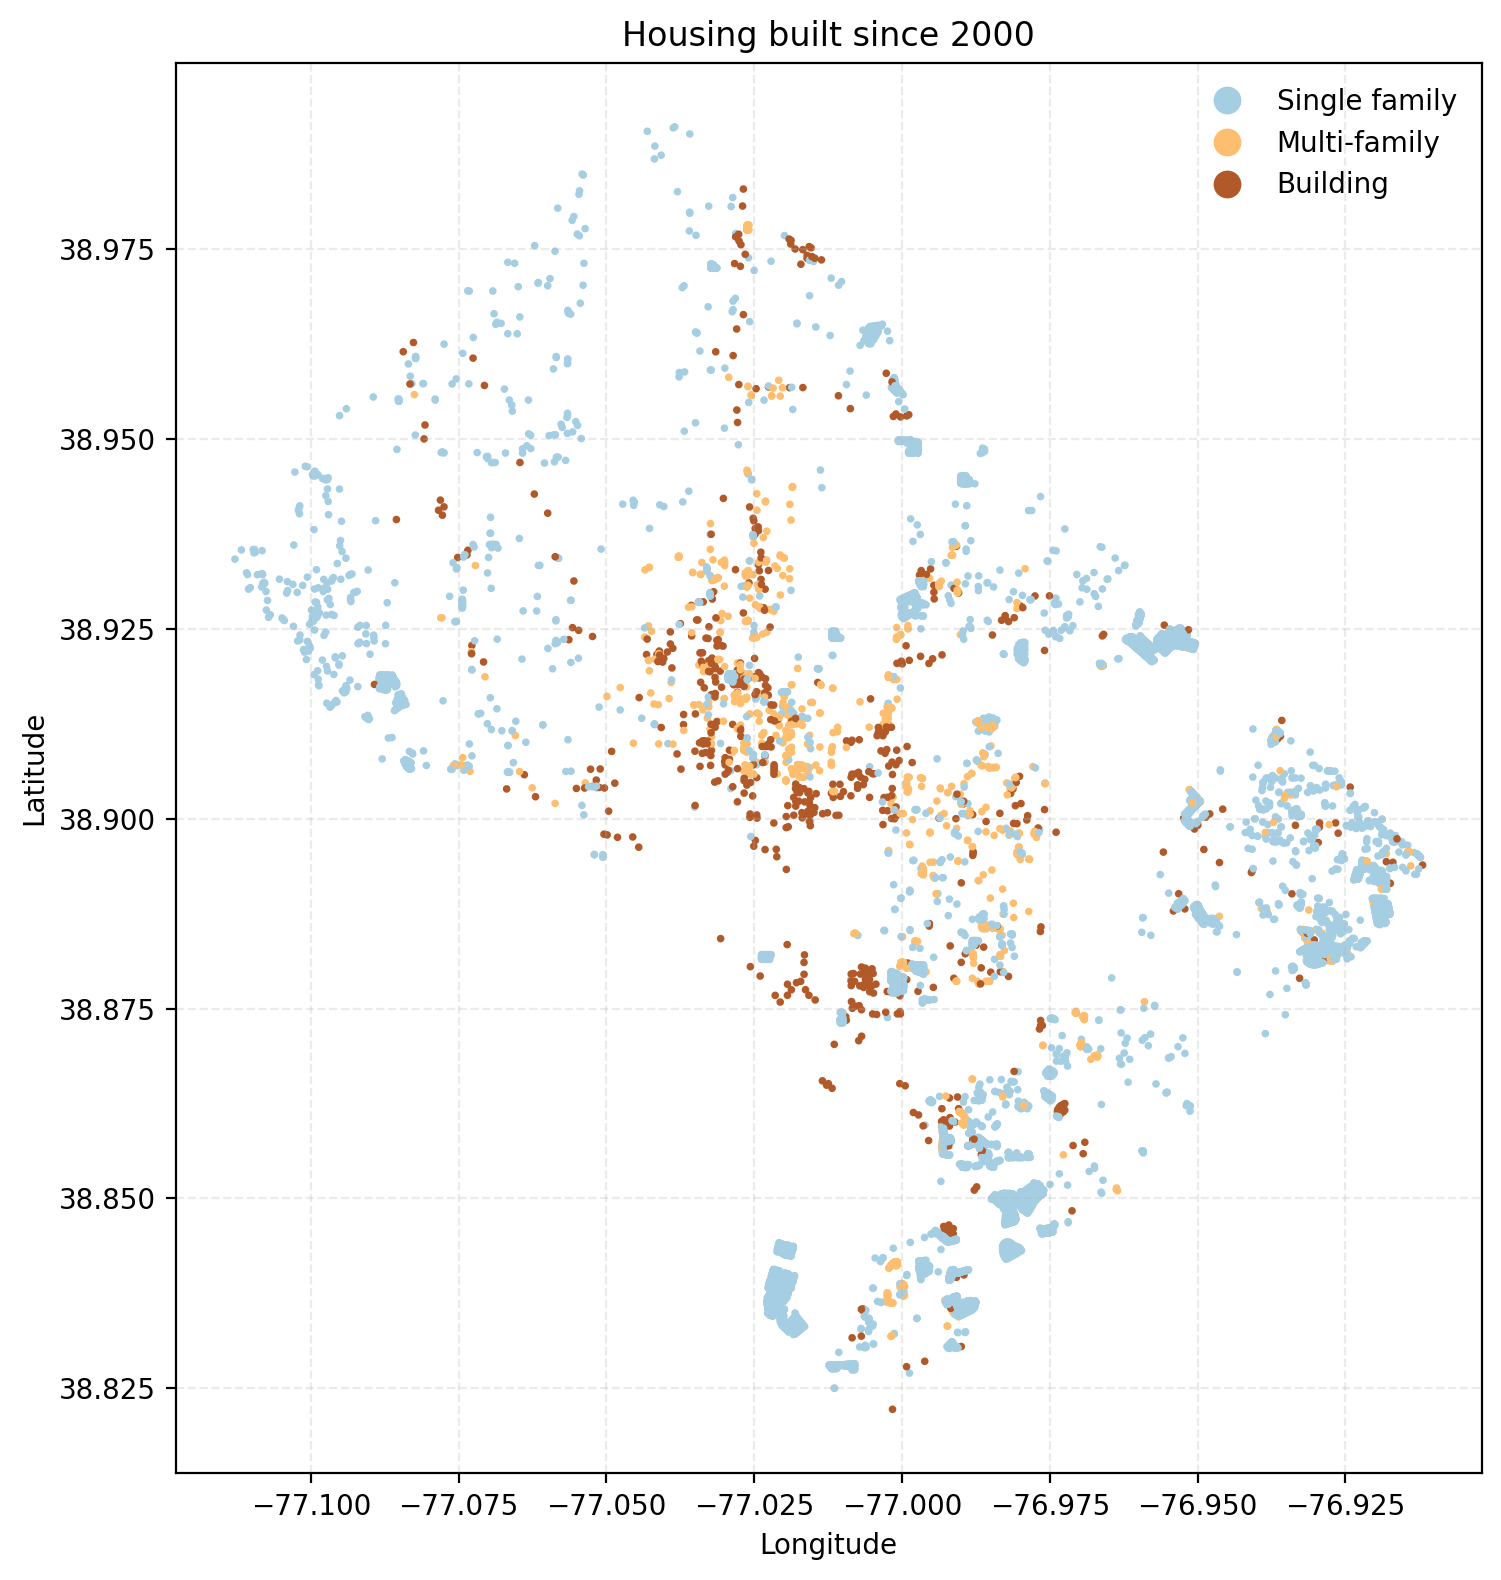

In [136]:
# Map spatial distribution of housing types
fig, ax = plt.subplots(figsize=(8,8), tight_layout=True)
df = address[address.year > 2000]
df.plot(column="housing_type", 
        cmap="Paired",
        #alpha=0.75, 
        categorical=True,
        markersize=3, 
        legend=True,
        legend_kwds={'frameon': False}, 
        ax=ax)
ax.set(xlabel="Longitude",
       ylabel="Latitude",
       title="Housing built since 2000")
ax.grid(zorder=0, ls="--", alpha=0.25)



### Time series view: Sum housing units by year of construction

In [137]:
# Sum buildings by year of construction
housing_type_starts = (address.groupby(["year","housing_type"], as_index=False)["total_housing_units"].size()
       .sort_values(by="year")).rename(columns={"size":"starts"})
housing_type_starts


,year,housing_type,starts
0,1901.0,Single family,463
1,1901.0,Multi-family,224
2,1901.0,Building,9
3,1902.0,Single family,496
4,1902.0,Multi-family,316
...,...,...,...
366,2023.0,Building,27
367,2024.0,Single family,25
368,2024.0,Multi-family,4
369,2024.0,Building,5


In [138]:
# Sum total_housing_units by year of construction
housing_starts = (address.groupby("year", as_index=False)["total_housing_units"].sum()
       .sort_values(by="year"))
# Compute cumulative housing starts
housing_starts["total_housing_cumsum"] = housing_starts["total_housing_units"].cumsum()

### Read ancillary data: DC population time series

In [139]:
# Load population data
pop = pd.read_csv(CSV_PATHS['population'])
pop["year"] = pd.to_datetime(pop["observation_date"]).dt.year
pop["population"] = pop["DCPOP"]*1000

# Drop redundant columns
pop = pop[["year","population"]]
pop.head()

,year,population
0,1900,278000.0
1,1901,285000.0
2,1902,290000.0
3,1903,295000.0
4,1904,302000.0


In [ ]:
# Merge address and population data
housing_starts = housing_starts.merge(pop, on="year", how='left')
housing_starts.head()

# Compute annual household size
housing_starts["household_size"] = housing_starts["population"] / housing_starts["total_housing_cumsum"]
# Compute effective people housed
housing_starts["people_housed"] = housing_starts["total_housing_units"]*housing_starts["household_size"]

# Compute effective housing units based on modern household size of 2 per housing unit
# df["EFFECTIVE_HOUSING_UNITS"] = df["HOUSING_UNIT_COUNT"] * df["household_size"]

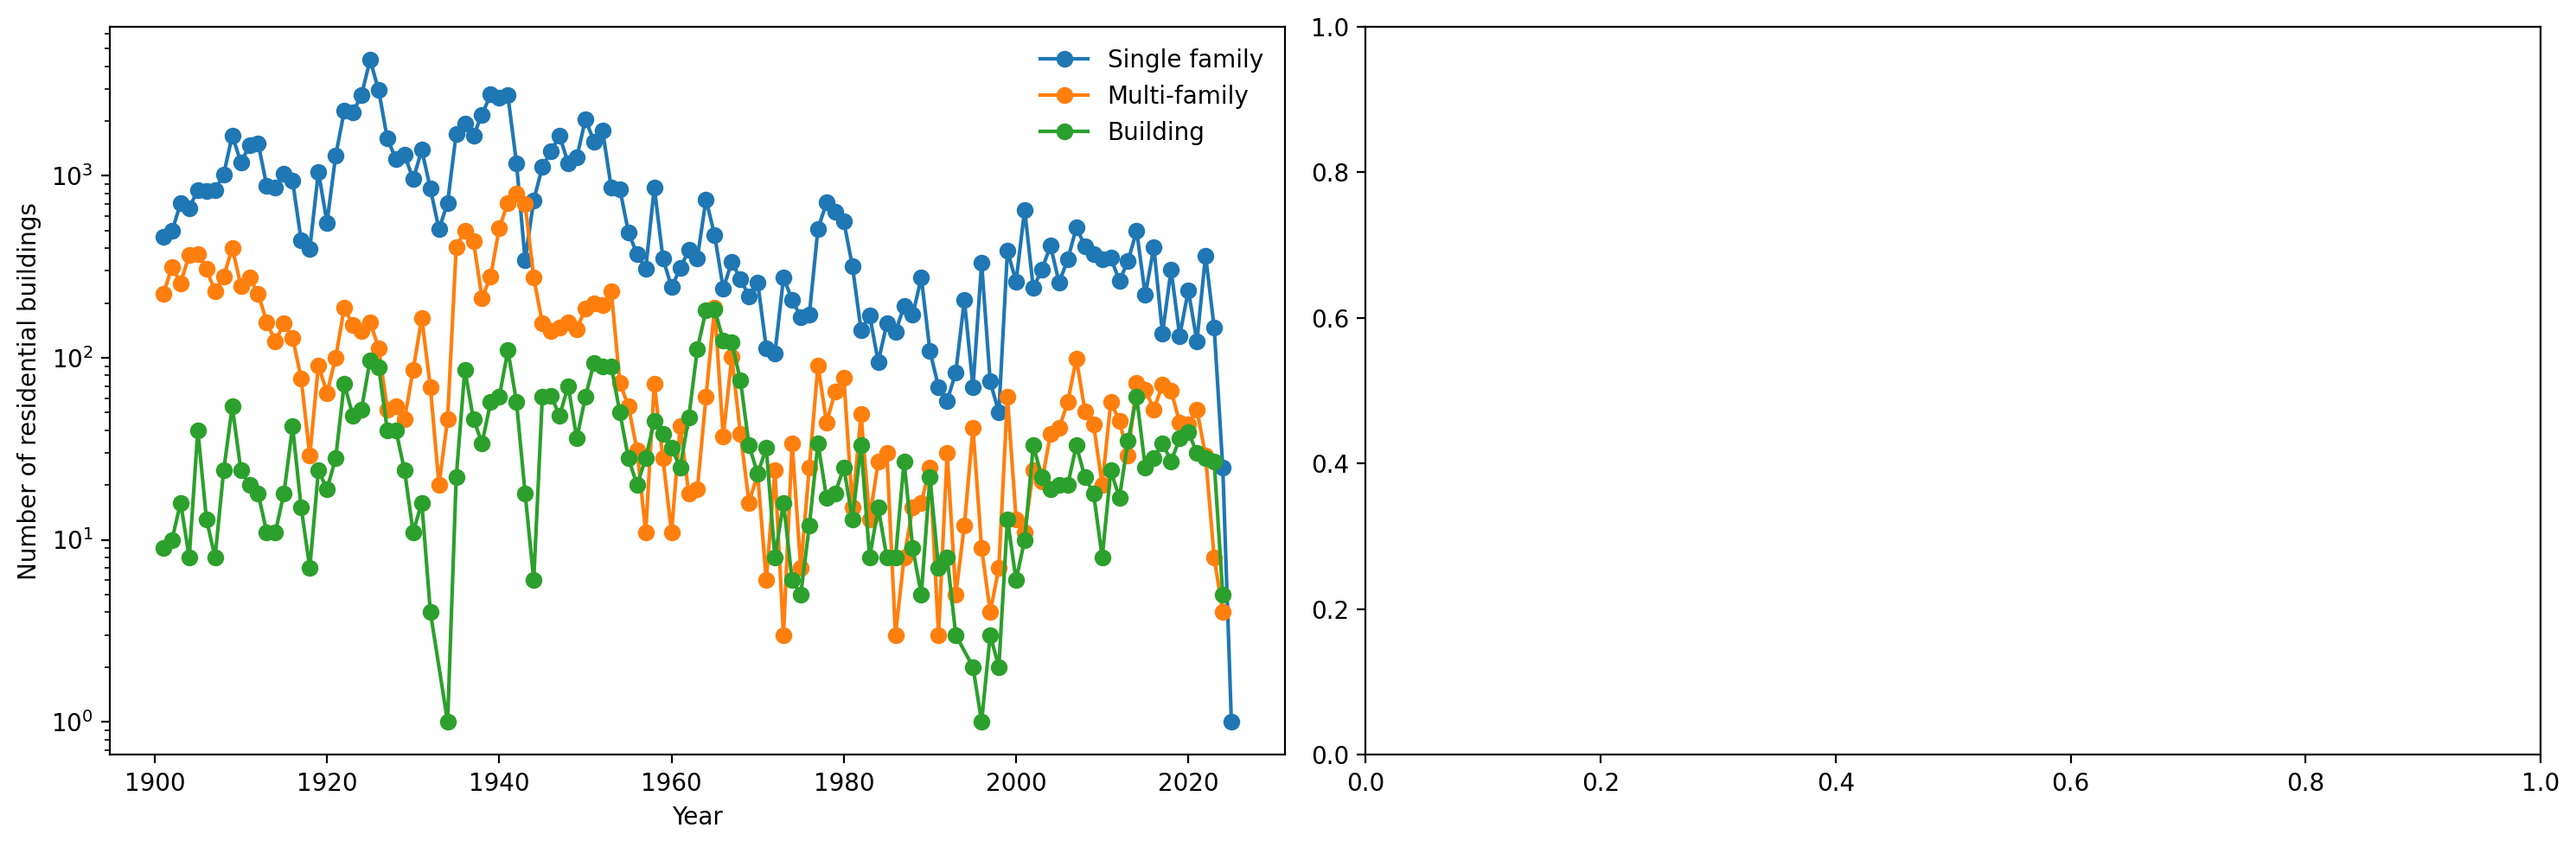

In [144]:
# Plot the number of new buildings by year
fig,(ax0,ax1) = plt.subplots(ncols=2, figsize=(15,5), tight_layout=True)
for housing_type in housing_type_starts["housing_type"].unique():
    tmp = housing_type_starts[housing_type_starts.housing_type == housing_type].reset_index(drop=True)
    ax0.plot(tmp["year"], tmp["starts"], marker='o', ls='-', label=housing_type)
ax0.set(xlabel="Year", ylabel="Number of residential buildings")
ax0.legend(frameon=False)
ax0.set_yscale('log')

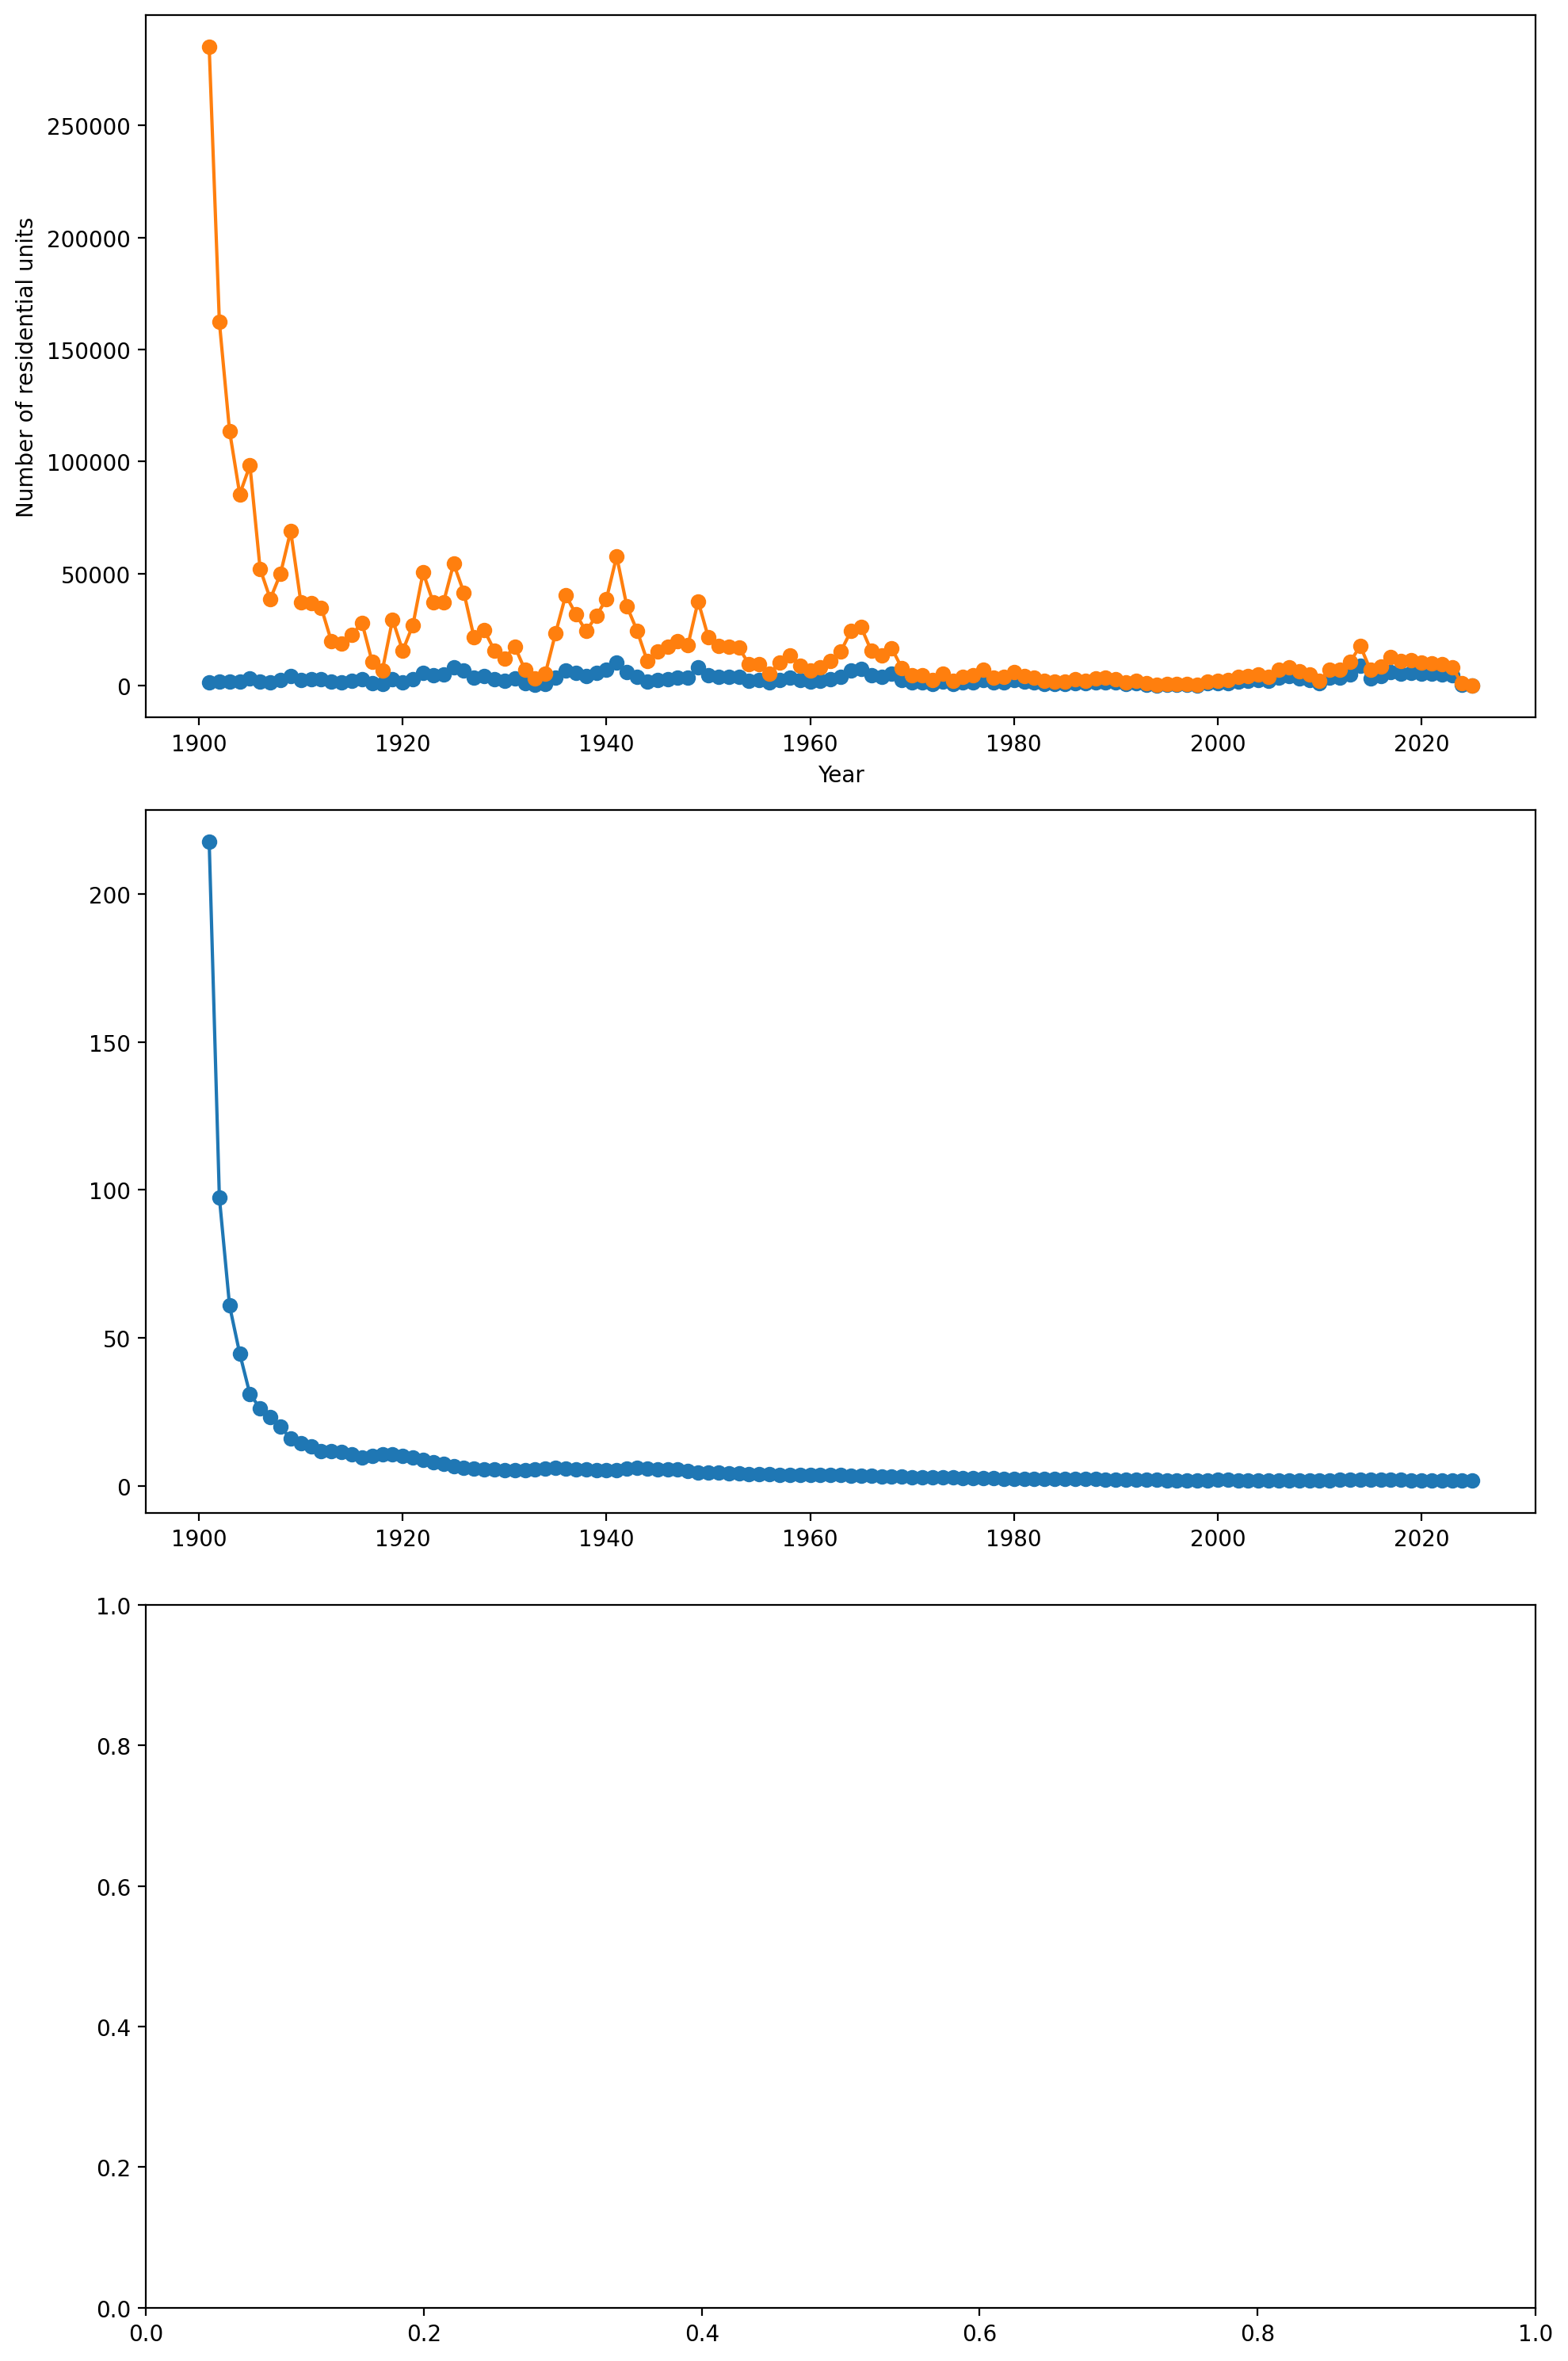

In [142]:
# Plot number of new housing units by year
fig,(ax0,ax1,ax2) = plt.subplots(nrows=3, figsize=(10,15), tight_layout=True)
ax0.plot(housing_starts["year"], housing_starts.total_housing_units, marker='o', ls='-')
ax0.set(xlabel="Year", ylabel="Number of residential units")
ax0.plot(housing_starts["year"], housing_starts["people_housed"], marker='o', ls='-')

ax1.plot(housing_starts["year"], housing_starts["household_size"], marker='o', ls='-', label="Housing Units per Capita")


[Text(0.5, 0, 'Year'), Text(0, 0.5, 'Number of residential units')]

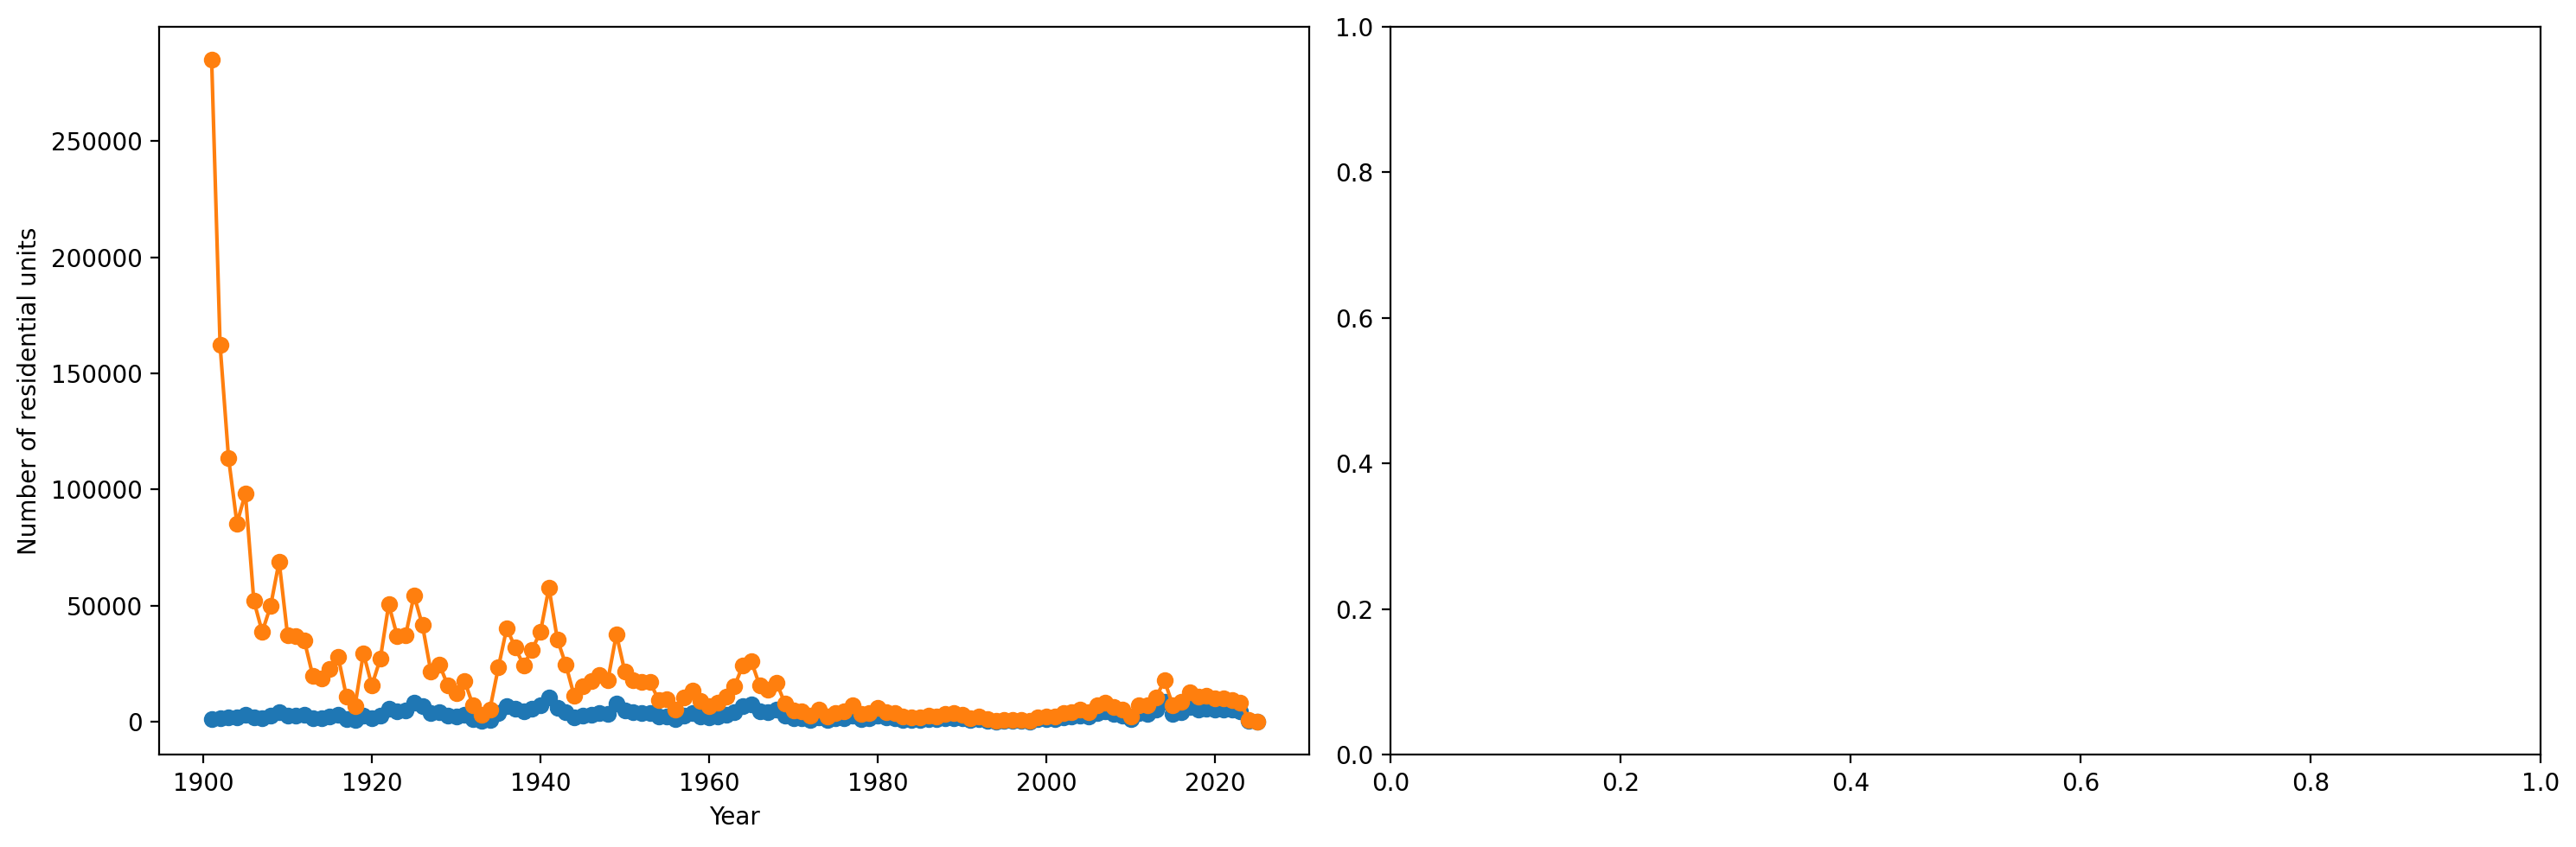

In [126]:
fig,(ax0,ax1) = plt.subplots(ncols=2, figsize=(15,5), tight_layout=True)
ax0.plot(housing_starts["year"], housing_starts.total_housing_units, marker='o', ls='-')
ax0.plot(housing_starts["year"], housing_starts["people_housed"], marker='o', ls='-')
ax0.set(xlabel="Year", ylabel="Number of residential units")

KeyError: 'BEGIN_YEAR'

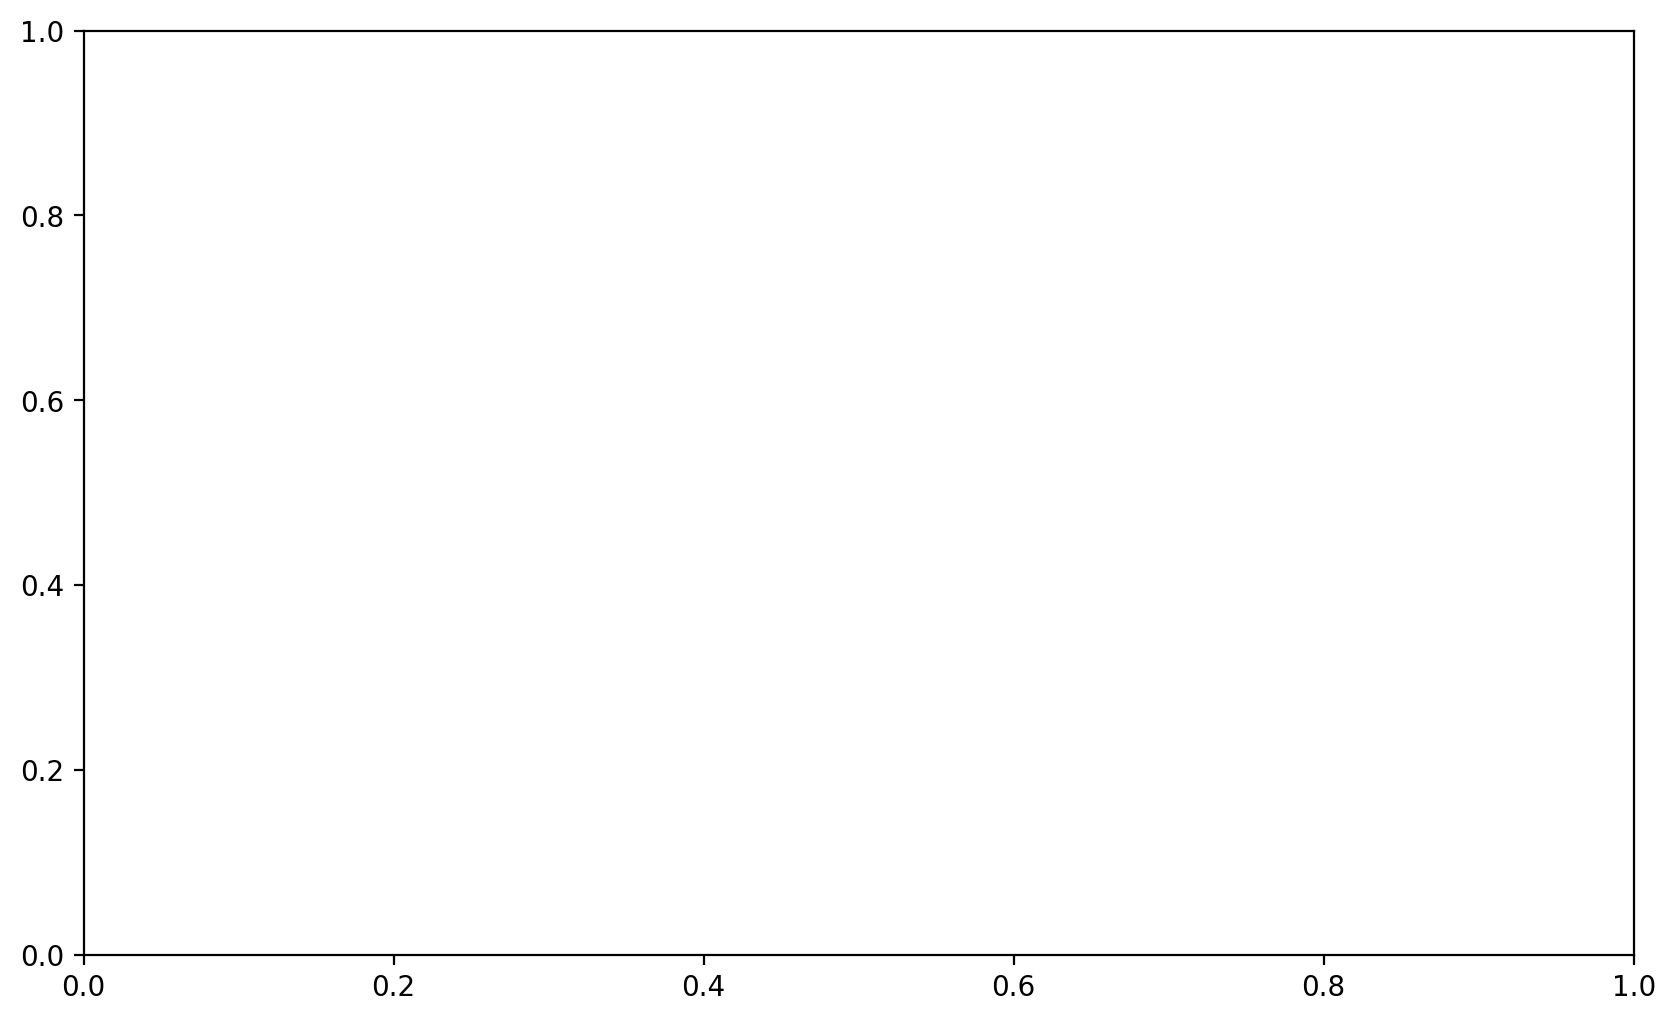

In [127]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df["BEGIN_YEAR"], df["HOUSING_UNIT_CUMSUM"], marker='o', ls='-', label="Cumulative Housing Units (thousands)")
ax.plot(df["BEGIN_YEAR"], df["population"], marker='o', ls='-', color='orange', label="Population")
ax.legend()

### Housing Appraisal

### Data prep

In [ ]:
# Read mass appraisal data
appraisal = pd.read_csv(CSV_PATHS['appraisal'])

# Columns of interest: "AVLAND", "AVTOTAL", "BLDGCL", "USECODE"
print(appraisal.columns)
appraisal.head()

Index(['OBJECTID', 'SSL', 'BATHRM', 'HF_BATHRM', 'HEAT', 'HEAT_D', 'AC',
       'NUM_UNITS', 'ROOMS', 'BEDRM', 'AYB', 'YR_RMDL', 'EYB', 'STORIES',
       'SALEDATE', 'PRICE', 'QUALIFIED', 'SALE_NUM', 'GBA', 'BLDG_NUM',
       'STYLE', 'STYLE_D', 'STRUCT', 'STRUCT_D', 'GRADE', 'GRADE_D', 'CNDTN',
       'CNDTN_D', 'EXTWALL', 'EXTWALL_D', 'ROOF', 'ROOF_D', 'INTWALL',
       'INTWALL_D', 'KITCHENS', 'FIREPLACES', 'USECODE', 'LANDAREA',
       'GIS_LAST_MOD_DTTM'],
      dtype='str')


,OBJECTID,SSL,BATHRM,HF_BATHRM,HEAT,HEAT_D,AC,NUM_UNITS,ROOMS,BEDRM,...,EXTWALL_D,ROOF,ROOF_D,INTWALL,INTWALL_D,KITCHENS,FIREPLACES,USECODE,LANDAREA,GIS_LAST_MOD_DTTM
0,184582008,0132 0216,5.0,1.0,1.0,Forced Air,Y,3.0,15.0,6.0,...,Stone/Stucco,2.0,Built Up,6.0,Hardwood,3.0,6.0,25,1381,2026/04/08 05:16:11+00
1,184582009,0132 0217,5.0,0.0,1.0,Forced Air,Y,5.0,13.0,5.0,...,Common Brick,2.0,Built Up,6.0,Hardwood,5.0,0.0,25,1381,2026/04/08 05:16:11+00
2,184582010,0132 0222,2.0,0.0,1.0,Forced Air,Y,1.0,8.0,5.0,...,Common Brick,6.0,Metal- Sms,6.0,Hardwood,1.0,1.0,11,1620,2026/04/08 05:16:11+00
3,184582011,0132 0223,4.0,1.0,8.0,Ht Pump,Y,1.0,12.0,4.0,...,Common Brick,2.0,Built Up,6.0,Hardwood,1.0,0.0,11,1575,2026/04/08 05:16:11+00
4,184582012,0132 0227,2.0,0.0,7.0,Warm Cool,Y,2.0,6.0,2.0,...,Common Brick,2.0,Built Up,6.0,Hardwood,2.0,2.0,24,2250,2026/04/08 05:16:11+00


In [157]:
# Extract sale year
appraisal["SALE_YEAR"] = pd.to_datetime(appraisal["SALEDATE"], errors='coerce').dt.year

# Compute median and mean price by year
annual_price = appraisal.groupby('SALE_YEAR')['PRICE'].agg(['mean', 'median']).reset_index()

# Minimal data pre-1980 (drop)
annual_price = annual_price[annual_price.SALE_YEAR > 1980].reset_index(drop=True)

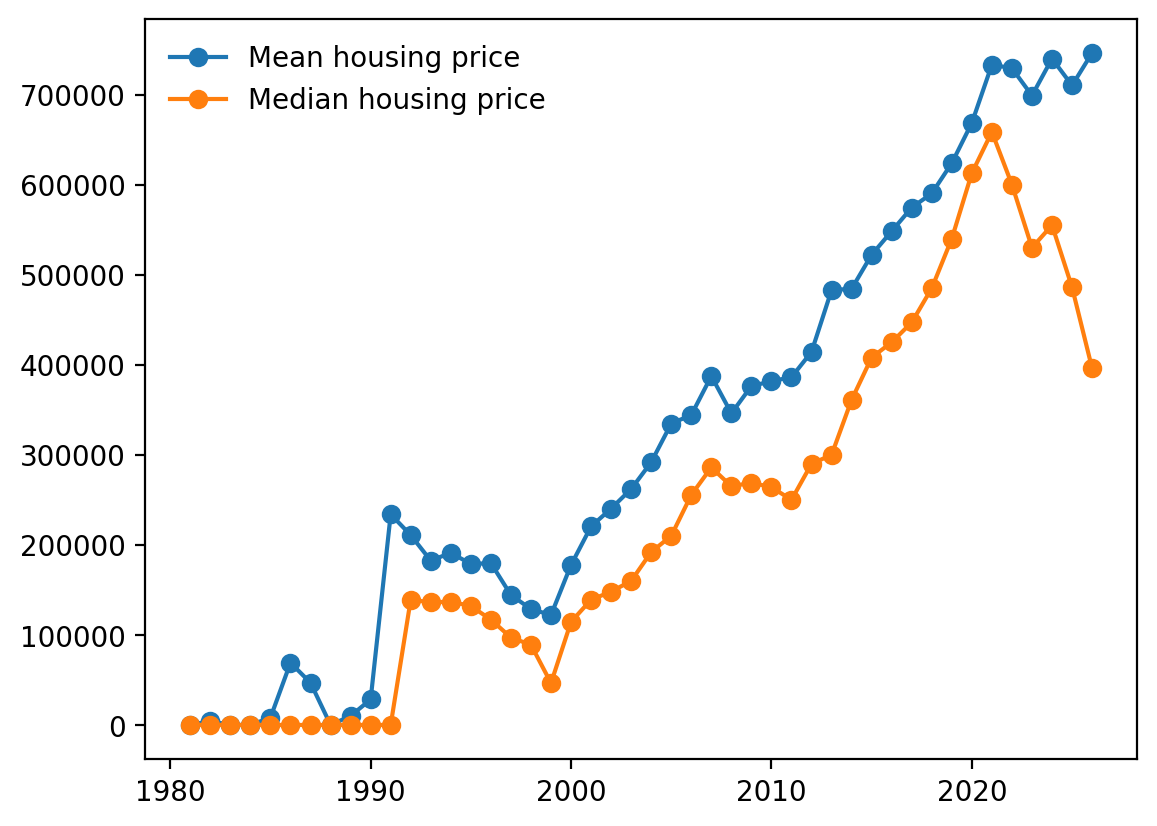

In [160]:
# Compute mean price by year
fig, ax = plt.subplots()
ax.plot(annual_price["SALE_YEAR"], annual_price["mean"], marker='o', ls='-', label="Mean housing price")
ax.plot(annual_price["SALE_YEAR"], annual_price["median"], marker='o', ls='-', label="Median housing price")
ax.legend(frameon=False)


In [213]:
# Compute annual rate of price increase
mean_price_by_year["price_increase_rate"] = mean_price_by_year["PRICE"].pct_change() * 100


In [219]:
mean_price_by_year[mean_price_by_year.SALE_YEAR == 2020]

,SALE_YEAR,PRICE,price_increase_rate
60,2020,669311.139424,7.528398


In [220]:
(669311.139424 - 177808.790576)/177808.790576 * 100

276.4218502672507

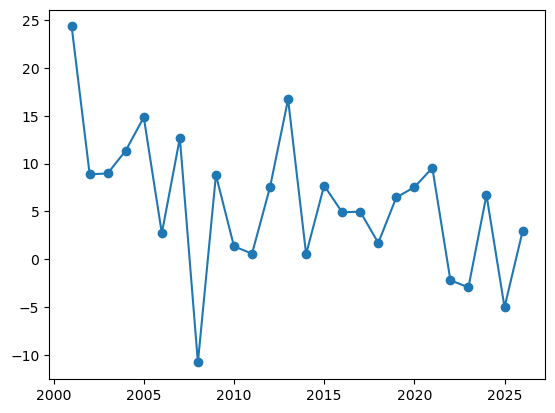

In [225]:
tmp2 = mean_price_by_year[mean_price_by_year.SALE_YEAR > 2000]
plt.plot(tmp2["SALE_YEAR"], tmp2["price_increase_rate"], marker='o', ls='-')

In [233]:
# Mean number of bedrooms by sale year
mean_bedrooms_by_year = appraisal.groupby("SALE_YEAR")["BEDRM"].median().reset_index()
mean_bedrooms_by_year

,SALE_YEAR,BEDRM
0,1900,3.0
1,1910,3.0
2,1956,3.0
3,1963,3.0
4,1964,3.0
...,...,...
62,2022,3.0
63,2023,3.0
64,2024,3.0
65,2025,3.0


<Axes: >

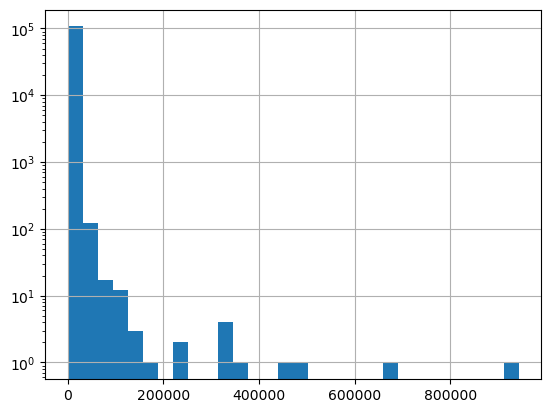

In [229]:
appraisal["LANDAREA"].hist(bins=30, log=True)

In [218]:
mean_price_by_year[mean_price_by_year.SALE_YEAR == 2000]

,SALE_YEAR,PRICE,price_increase_rate
40,2000,177808.790576,45.449653


In [217]:
mean_price_by_year[mean_price_by_year.SALE_YEAR > 2000]["price_increase_rate"].mean()

np.float64(5.800005201284565)

In [204]:
# Drop buildings without bedrooms
appraisal = appraisal[appraisal["BEDRM"] > 0].reset_index(drop=True)

<Axes: xlabel='STORIES'>

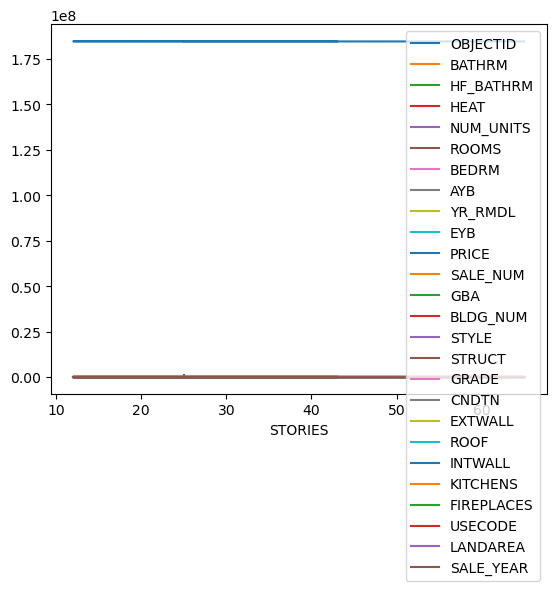

In [210]:
appraisal[appraisal["STORIES"] > 10].plot("STORIES", markersize=4)

# Remnants

In [ ]:
appraisal = appraisal[appraisal.NUM_UNITS > 0].reset_index(drop=True)

In [ ]:
appraisal["rooms_per_unit"] = appraisal.ROOMS / appraisal.NUM_UNITS
appraisal["bedrooms_per_unit"] = appraisal.BEDRM / appraisal.NUM_UNITS
appraisal["rooms_per_unit"].value_counts().sort_index()

rooms_per_unit
0.000000     338
0.500000       3
0.583333       1
0.750000       2
1.000000      53
            ... 
36.000000      1
37.000000      1
39.000000      2
41.000000      1
48.000000      1
Name: count, Length: 96, dtype: int64

NameError: name 'appraisal' is not defined

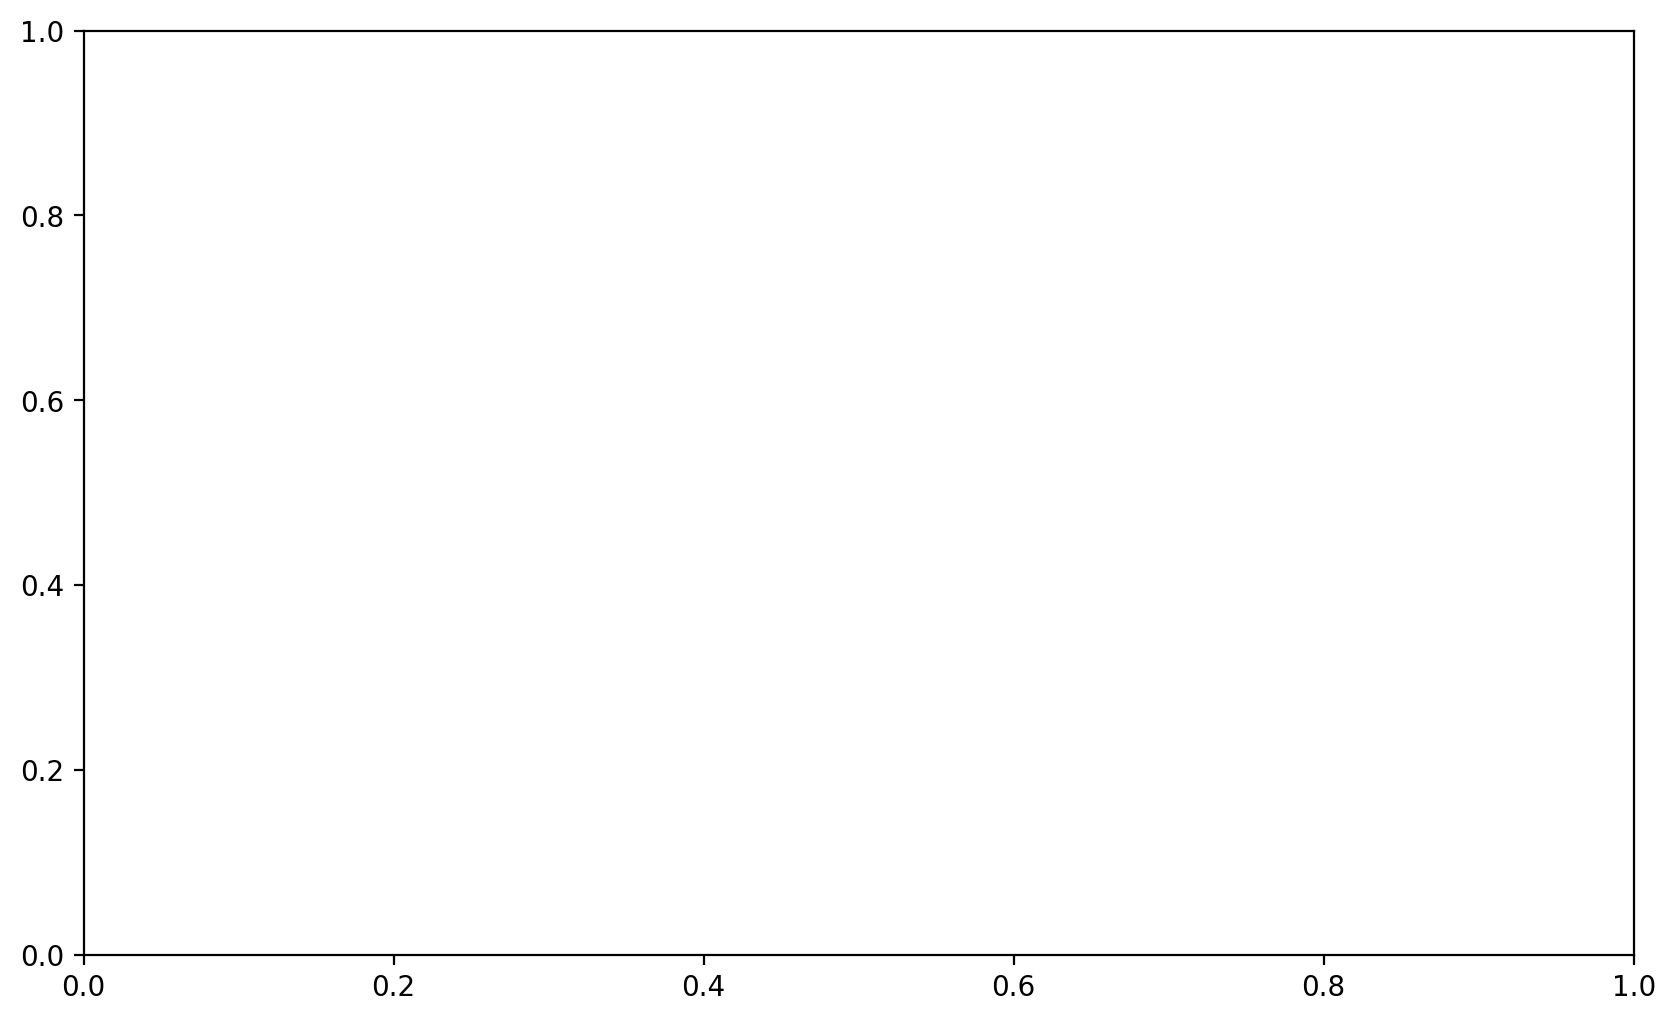

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
appraisal.bedrooms_per_unit.hist(bins=30, ax=ax)
ax.axvline(2, color='red', linestyle='--', label='1 room per unit')

In [ ]:
appraisal[["NUM_UNITS","ROOMS","BEDRM", "KITCHENS","GBA","PRICE"]].head()

,NUM_UNITS,ROOMS,BEDRM,KITCHENS,GBA,PRICE
0,3.0,15.0,6.0,3.0,3542,0.0
1,5.0,13.0,5.0,5.0,3249,NaN
2,1.0,8.0,5.0,1.0,2568,NaN
3,1.0,12.0,4.0,1.0,2514,2235000.0
4,2.0,6.0,2.0,2.0,3290,0.0


In [ ]:
appraisal["NUM_UNITS"].value_counts()

NUM_UNITS
1.0     92752
2.0     10442
4.0      2848
3.0      1088
0.0       165
5.0       122
7.0         3
9.0         1
12.0        1
8.0         1
Name: count, dtype: int64

<Axes: >

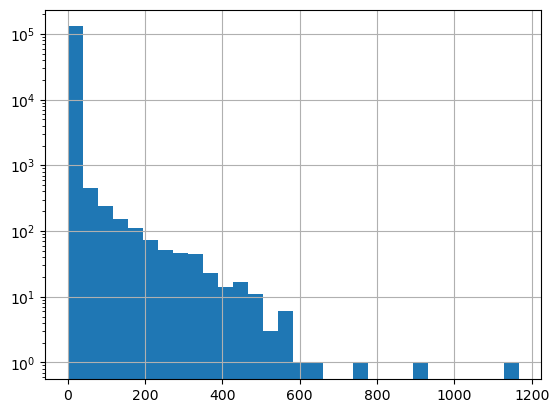

In [ ]:
address["HOUSING_UNIT_COUNT"].hist(bins=30, log=True)

<Axes: >

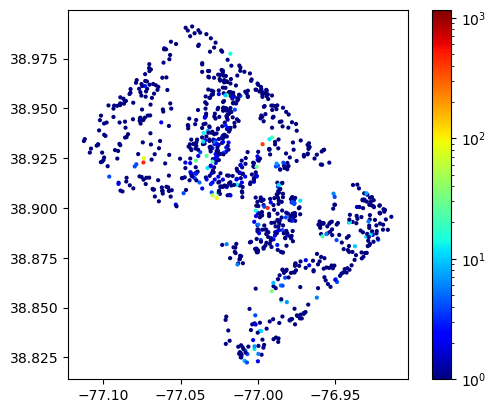

In [ ]:
address_samp.plot(column="HOUSING_UNIT_COUNT", 
                  norm=LogNorm(1, address["HOUSING_UNIT_COUNT"].max()),
                  cmap="jet", markersize=4, legend=True)

<Axes: >

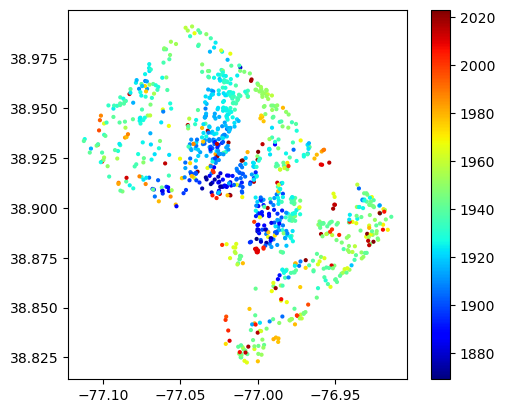

In [ ]:
address_samp.plot(column="BEGIN_YEAR", cmap="jet", markersize=4, legend=True)

In [ ]:
# Create complete date list to identify missing dates
crimes_date_range = pd.date_range(start=crimes_by_day['report_daily'].min(), 
                           end=crimes_by_day['report_daily'].max(), freq='D')

# Ensure crimes_by_day['report_daily'] is datetime object for comparison
crimes_by_day['report_daily'] = pd.to_datetime(crimes_by_day['report_daily'])

# Extract dates missing from crimes_by_day 
idx = ~crimes_date_range.isin(crimes_by_day['report_daily'])

# No missing dates in crimes_by_day
print(f"{sum(idx)} missing dates in crimes_by_day")

0 missing dates in crimes_by_day


In [ ]:
# Create complete date list to identify missing dates
stops_date_range = pd.date_range(start=stops_by_day['stop_date'].min(), 
                           end=stops_by_day['stop_date'].max(), freq='D')

# Ensure stops_by_day['stop_date'] is datetime object for comparison
stops_by_day['stop_date'] = pd.to_datetime(stops_by_day['stop_date'])

# Extract dates missing from stops_by_day
idx = ~stops_date_range.isin(stops_by_day['stop_date'])

# NOTE: 8 dates missing from stops_by_day
print(f"{sum(idx)} missing dates in stops_by_day")

8 missing dates in stops_by_day


In [ ]:
stops_by_day = (stops_by_day.set_index('stop_date')
                .resample('D')
                .asfreq()
                .fillna(0)).reset_index(drop=True)

print(f"len(crimes_by_day): {len(crimes_by_day)}")
print(f"len(stops_by_day): {len(stops_by_day)}")

Index(['NAME', 'STATION_TYPE', 'STATION_ID', 'STATION_STATUS', 'LAST_REPORTED',
       'NUM_DOCKS_AVAILABLE', 'NUM_DOCKS_DISABLED', 'NUM_BIKES_AVAILABLE',
       'NUM_EBIKES_AVAILABLE', 'NUM_BIKES_DISABLED', 'IS_INSTALLED',
       'IS_RETURNING', 'IS_RENTING', 'HAS_KIOSK', 'IOS', 'ANDROID',
       'ELECTRIC_BIKE_SURCHARGE_WAIVER', 'EIGHTD_HAS_KEY_DISPENSER',
       'CAPACITY', 'RENTAL_METHODS', 'REGION_ID', 'REGION_NAME', 'GIS_ID',
       'LATITUDE', 'LONGITUDE', 'GIS_LAST_MOD_DTTM', 'OBJECTID', 'geometry'],
      dtype='str')


<Axes: >

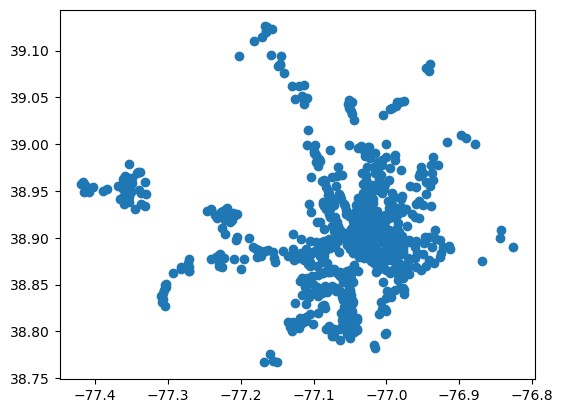

In [ ]:
# Read bike share locations data
# Columns of interest: "NUM_DOCKS_AVAILABLE", "NUM_BIKES_AVAILABLE", "IS_RENTING", "IS_RETURNING"
bike_share_locations = gpd.read_file(GEOJSON_PATHS['bike_share_locations'])
print(bike_share_locations.columns)
bike_share_locations.plot()

Index(['ROUTEID', 'ROUTENAME', 'ROADTYPE', 'SUBBLOCKKEY',
       'BIKELANE_PARKINGLANE_ADJACENT', 'BIKELANE_THROUGHLANE_ADJACENT',
       'BIKELANE_POCKETLANE_ADJACENT', 'BIKELANE_CONTRAFLOW',
       'BIKELANE_CONVENTIONAL', 'BIKELANE_DUAL_PROTECTED',
       'BIKELANE_DUAL_BUFFERED', 'BIKELANE_PROTECTED', 'BIKELANE_BUFFERED',
       'SUBBLOCKID', 'BLOCKID', 'BLOCKKEY', 'QUADRANT', 'STREETNAME',
       'STREETTYPE', 'TOTALBIKELANES', 'TOTALBIKELANEWIDTH', 'WARD_ID',
       'SMD_ID', 'ANC_ID', 'OBJECTID', 'SHAPELEN', 'geometry'],
      dtype='str')


<Axes: >

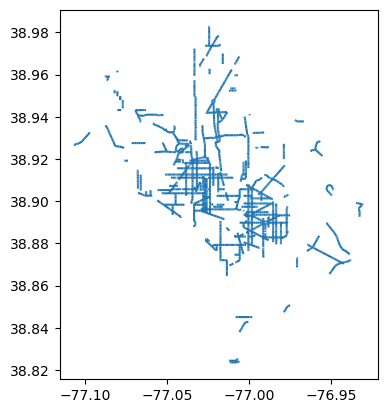

In [ ]:
# Read bike lanes data
# COLUMNS OF INTEREST: "ROADTYPE", "TOTALBIKELANEWIDTH", "BIKELANE_PROTECTED", "BIKELANE_BUFFERED"
bike_lanes = gpd.read_file(GEOJSON_PATHS['bike_lanes'])
print(bike_lanes.columns)
bike_lanes.plot()

In [ ]:
# 
housing_cols = {
    "DP04_0038E": "total_units",
    "DP04_0020E": "occupied_units"
}


In [ ]:
# Read housing characteristics data
housing = gpd.read_file(GEOJSON_PATHS['housing_characteristics'])
print(housing.columns)

# Rename columns of interest
housing = housing.rename(columns=housing_cols)


Index(['NAME', 'DP04_0038E', 'DP04_0040E', 'DP04_0041E', 'DP04_0042E',
       'DP04_0043E', 'DP04_0044E', 'DP04_0039E', 'GEOID', 'GIS_ID',
       ...
       'DP04_0023E', 'DP04_0022E', 'DP04_0021E', 'DP04_0020E', 'DP04_0019E',
       'DP04_0018E', 'DP04_0017E', 'TRACTCE', 'OBJECTID', 'geometry'],
      dtype='str', length=152)


In [ ]:
# Extract numeric columns
nonnumeric_cols = ["GIS_ID","geometry"]
numeric_cols = [col for col in housing.columns if col not in nonnumeric_cols]

# Convert numeric columns to numeric type, coercing errors to NaN
# Remove thousands separator commas, which cause conversion to numeric to fail
housing = housing.replace(',', '', regex=True)
housing[numeric_cols] = housing[numeric_cols].apply(pd.to_numeric, errors='coerce')
housing.head(10)

,NAME,total_units,DP04_0040E,DP04_0041E,DP04_0042E,DP04_0043E,DP04_0044E,DP04_0039E,GEOID,GIS_ID,...,DP04_0023E,DP04_0022E,DP04_0021E,occupied_units,DP04_0019E,DP04_0018E,DP04_0017E,TRACTCE,OBJECTID,geometry
0,1.01,898,442,166,45,45,50,150,11001000101,ACS_Housing_DC_CensusTract_11,...,57,26,19,8,15,19,0,101,11,"POLYGON ((-77.05121 38.91078, -77.05126 38.910..."
1,1.02,2207,464,625,507,284,158,169,11001000102,ACS_Housing_DC_CensusTract_8,...,197,30,40,30,12,0,0,102,8,"POLYGON ((-77.0669 38.91866, -77.06726 38.9186..."
2,2.01,0,0,0,0,0,0,0,11001000201,ACS_Housing_DC_CensusTract_100,...,0,0,0,0,0,0,0,201,100,"POLYGON ((-77.07412 38.91259, -77.07433 38.912..."
3,2.02,1977,294,512,748,195,184,44,11001000202,ACS_Housing_DC_CensusTract_141,...,68,51,424,10,22,54,0,202,141,"POLYGON ((-77.06568 38.91183, -77.06583 38.912..."
4,3.00,2793,718,363,730,607,312,63,11001000300,ACS_Housing_DC_CensusTract_101,...,67,62,338,84,50,101,0,300,101,"POLYGON ((-77.0743 38.92256, -77.0747 38.92256..."
5,4.00,885,156,187,94,92,281,75,11001000400,ACS_Housing_DC_CensusTract_102,...,19,66,99,68,59,210,15,400,102,"POLYGON ((-77.06639 38.92753, -77.06639 38.928..."
6,5.01,2559,1028,667,180,33,104,547,11001000501,ACS_Housing_DC_CensusTract_126,...,555,151,299,107,75,183,0,501,126,"POLYGON ((-77.04452 38.92835, -77.04454 38.928..."
7,5.02,1815,671,454,191,221,185,93,11001000502,ACS_Housing_DC_CensusTract_103,...,80,55,10,6,0,58,0,502,103,"POLYGON ((-77.05699 38.93258, -77.05707 38.932..."
8,6.00,2287,653,262,243,244,620,265,11001000600,ACS_Housing_DC_CensusTract_110,...,111,21,57,0,16,44,0,600,110,"POLYGON ((-77.07508 38.94223, -77.07601 38.942..."
9,7.02,2503,1223,569,100,12,13,586,11001000702,ACS_Housing_DC_CensusTract_111,...,568,243,56,26,9,0,0,702,111,"POLYGON ((-77.08051 38.92601, -77.0813 38.9260..."


In [ ]:
# Compute area in hectares
housing['area_ha'] = housing.to_crs(DC_UTM_EPSG).area / 10000

/Users/carlossilva/miniforge3/envs/base-env/lib/python3.14/site-packages/geopandas/geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)


In [ ]:
housing["unit_density"] = housing["total_units"] / housing["area_ha"]

<Axes: >

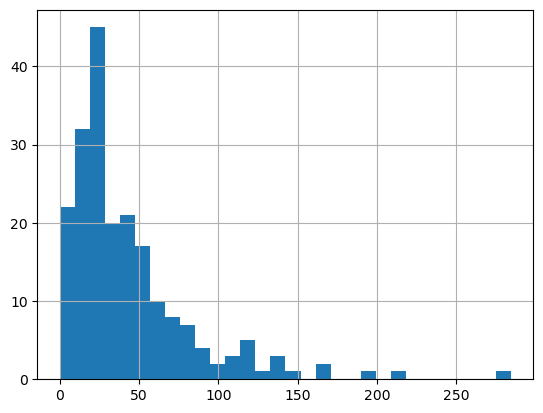

In [ ]:
housing["unit_density"].hist(bins=30)

<Axes: >

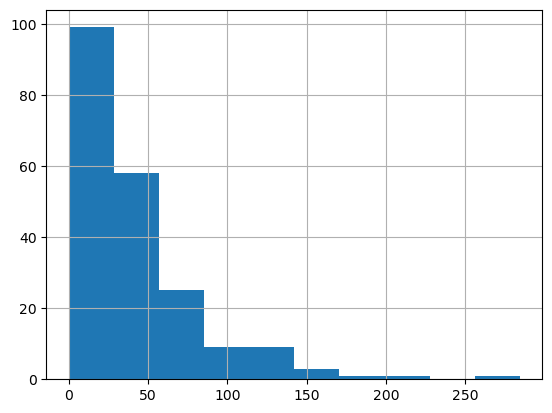

In [ ]:
housing['unit_density'].hist()